In [1]:
from Bio.PDB import PDBList
import os

pdbl = PDBList()
os.makedirs('./structures', exist_ok=True)
os.makedirs('./figures', exist_ok=True)

pdb_ids = ['2TMV', '1AYO', '1E6J', '2MS2']

for pdb_id in pdb_ids:
    pdbl.retrieve_pdb_file(pdb_id, pdir='./structures')

print(os.listdir('./structures'))

Structure exists: './structures/2tmv.cif' 
Structure exists: './structures/1ayo.cif' 
Structure exists: './structures/2ms2.cif' 
['2tmv.cif', '3j3y.cif', '2ms2.cif', '1ayo.cif', '1e6j.cif']


In [2]:
from Bio.PDB import MMCIFParser

parser = MMCIFParser(QUIET=True)

structures = {}
pdb_ids = ['2TMV', '1AYO', '1E6J', '2MS2']

for pdb_id in pdb_ids:
    path = f'./structures/{pdb_id.lower()}.cif'
    structure = parser.get_structure(pdb_id, path)
    structures[pdb_id] = structure
    
    atoms = list(structure.get_atoms())
    residues = [r for r in structure.get_residues() if r.id[0] == ' ']
    
    print(f"{pdb_id}: цепей — {len(list(structure.get_chains()))}, "
          f"остатков — {len(residues)}, "
          f"атомов — {len(atoms)}")

2TMV: цепей — 2, остатков — 157, атомов — 1354
1AYO: цепей — 3, остатков — 260, атомов — 2370
1E6J: цепей — 3, остатков — 639, атомов — 4976
2MS2: цепей — 3, остатков — 387, атомов — 3065


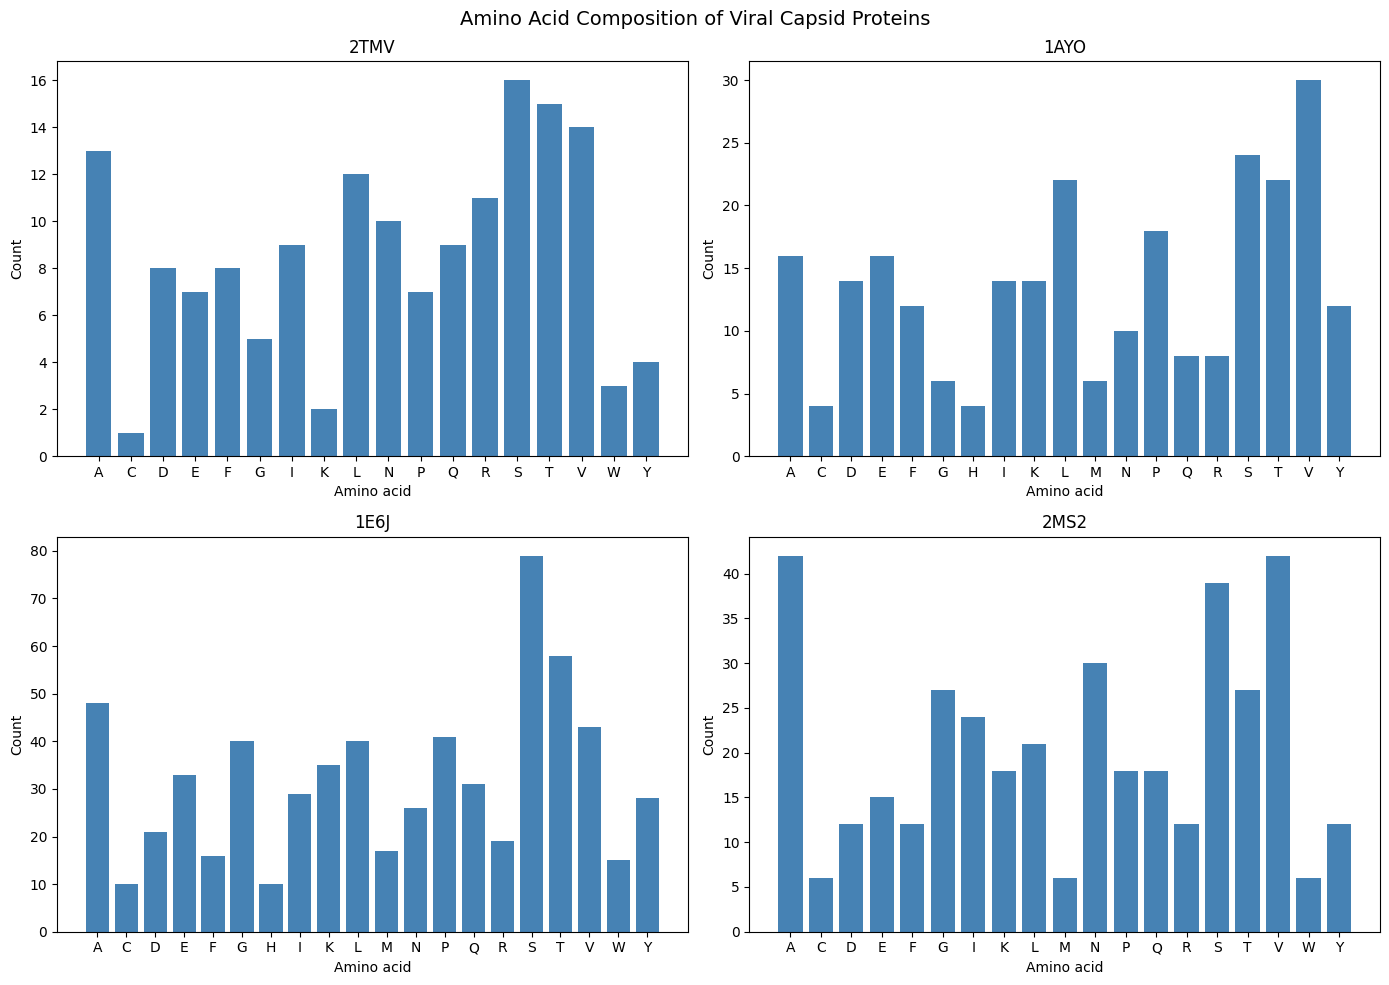

Готово


In [3]:
from Bio.PDB import PPBuilder
from collections import Counter
import matplotlib.pyplot as plt

ppb = PPBuilder()
composition = {}

for pdb_id, structure in structures.items():
    aa_counts = Counter()
    for pp in ppb.build_peptides(structure):
        seq = str(pp.get_sequence())
        aa_counts.update(seq)
    composition[pdb_id] = aa_counts

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (pdb_id, counts) in enumerate(composition.items()):
    letters = sorted(counts.keys())
    values = [counts[l] for l in letters]
    axes[i].bar(letters, values, color='steelblue')
    axes[i].set_title(f'{pdb_id}')
    axes[i].set_xlabel('Amino acid')
    axes[i].set_ylabel('Count')

plt.suptitle('Amino Acid Composition of Viral Capsid Proteins', fontsize=14)
plt.tight_layout()
plt.savefig('./figures/amino_acid_composition.png', dpi=150)
plt.show()
print("Готово")

In [4]:
from Bio.PDB import DSSP

secondary = {}

for pdb_id, structure in structures.items():
    path = f'./structures/{pdb_id.lower()}.cif'
    model = structure[0]
    
    try:
        dssp = DSSP(model, path, file_type='MMCIF')
        
        counts = Counter()
        for key in dssp:
            ss = key[2]
            counts[ss] += 1
        
        secondary[pdb_id] = counts
        print(f"{pdb_id}: {dict(counts)}")
    except Exception as e:
        print(f"{pdb_id}: ошибка — {e}")

2TMV: {'-': 38, 'S': 24, 'T': 16, 'H': 64, 'E': 7, 'I': 5}
1AYO: {'-': 44, 'S': 48, 'E': 124, 'G': 8, 'T': 20, 'B': 2, 'H': 14}
1E6J: {'-': 133, 'E': 232, 'T': 65, 'S': 38, 'G': 24, 'B': 6, 'H': 133, 'I': 5}
2MS2: {'-': 68, 'S': 29, 'E': 168, 'T': 44, 'G': 15, 'H': 63}


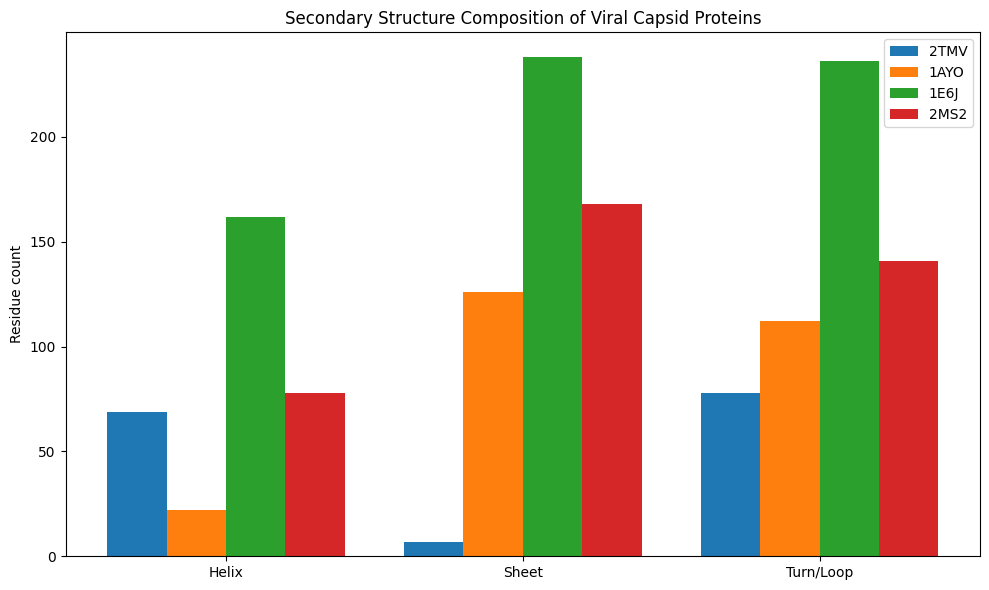

Готово


In [5]:
# Группируем по типам вторичной структуры
ss_groups = {
    'Helix': ['H', 'G', 'I'],
    'Sheet': ['E', 'B'],
    'Turn/Loop': ['T', 'S', '-']
}

grouped = {}
for pdb_id, counts in secondary.items():
    grouped[pdb_id] = {
        group: sum(counts.get(code, 0) for code in codes)
        for group, codes in ss_groups.items()
    }

# График
labels = list(ss_groups.keys())
x = range(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, (pdb_id, values) in enumerate(grouped.items()):
    heights = [values[l] for l in labels]
    offset = (i - 1.5) * width
    ax.bar([xi + offset for xi in x], heights, width, label=pdb_id)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Residue count')
ax.set_title('Secondary Structure Composition of Viral Capsid Proteins')
ax.legend()

plt.tight_layout()
plt.savefig('./figures/secondary_structure.png', dpi=150)
plt.show()
print("Готово")

In [6]:
import nglview as nv

# Смотрим каждую структуру по очереди
# Запускай отдельно для каждой если хочешь посмотреть все

view = nv.show_biopython(structures['2TMV'])
view.add_cartoon(color='residueindex')
view

NGLWidget()